In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
np.set_printoptions(precision=3, suppress=True)

CLASS_COLORS = {0: "#2a9d8f", 1: "#e76f51"}


In [2]:
cricket = pd.DataFrame({
    "Weather": [
        "Sunny", "Sunny", "Overcast", "Rain", "Rain", "Rain", "Overcast",
        "Sunny", "Sunny", "Rain", "Sunny", "Overcast", "Overcast", "Rain"
    ],
    "Temperature": [
        "Hot", "Hot", "Hot", "Mild", "Cool", "Cool", "Cool",
        "Mild", "Cool", "Mild", "Mild", "Mild", "Hot", "Mild"
    ],
    "Humidity": [
        "High", "High", "High", "High", "Normal", "Normal", "Normal",
        "High", "Normal", "Normal", "Normal", "High", "Normal", "High"
    ],
    "Wind": [
        "Weak", "Strong", "Weak", "Weak", "Weak", "Strong", "Strong",
        "Weak", "Weak", "Weak", "Strong", "Strong", "Weak", "Strong"
    ],
    "Play": [
        "No", "No", "Yes", "Yes", "Yes", "No", "Yes",
        "No", "Yes", "Yes", "Yes", "Yes", "Yes", "No"
    ]
})

print("Shape:", cricket.shape)
cricket


Shape: (14, 5)


,Weather,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [5]:
target_counts = cricket["Play"].value_counts()
target_counts = cricket["Play"].value_counts(normalize=True)

In [6]:
target_counts

,proportion
Play,
Yes,0.642857
No,0.357143


In [7]:
def entropy_from_probabilities(probs):
    return -sum(p * np.log2(p) for p in probs if p > 0)

In [8]:
entropy_from_probabilities([9/14, 5/14])

np.float64(0.9402859586706311)

In [13]:
labels = cricket["Play"]
unique_labels, counts = np.unique(labels, return_counts=True)
probs = counts / len(labels)
parent_entropy = entropy_from_probabilities(probs)

In [14]:
def entropy(labels):
    labels = np.asarray(labels)
    unique_labels, counts = np.unique(labels, return_counts=True)
    probs = counts / len(labels)
    return entropy_from_probabilities(probs)

In [16]:
mask = cricket["Weather"] == "Sunny"
sunny_entropy = entropy(cricket.loc[mask, "Play"])
sunny_entropy

np.float64(0.9709505944546686)

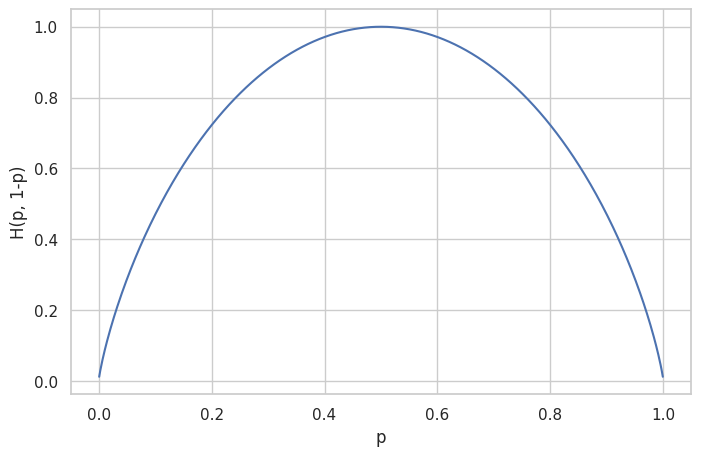

In [20]:
p_values = np.linspace(0.001, 0.999, 500)
h_values = [entropy_from_probabilities([p, 1 - p]) for p in p_values]

plt.plot(p_values, h_values)
plt.xlabel("p")
plt.ylabel("H(p, 1-p)")
plt.show()

In [21]:
weather_counts = pd.crosstab(cricket["Weather"], cricket["Play"])
weather_counts

Play,No,Yes
Weather,,
Overcast,0,4
Rain,2,3
Sunny,3,2


In [29]:
inf_gain_weather = parent_entropy
entropy_weather = 0.0
for weather_value, group in cricket.groupby("Weather"):
    print(f"{weather_value=}")
    print(f"{group=}")

    print(f'{entropy(group["Play"])=:.4f}')

    weight = len(group) / len(cricket)
    print(f"{weight=:.4f}")

    contribution = weight * entropy(group["Play"])
    print(f"{contribution=:.4f}")
    print()
    entropy_weather += contribution

print(f"{entropy_weather=:.4f}")
inf_gain_weather -= entropy_weather
print(f"{inf_gain_weather=:.4f}")


weather_value='Overcast'
group=     Weather Temperature Humidity    Wind Play
2   Overcast         Hot     High    Weak  Yes
6   Overcast        Cool   Normal  Strong  Yes
11  Overcast        Mild     High  Strong  Yes
12  Overcast         Hot   Normal    Weak  Yes
entropy(group["Play"])=-0.0000
weight=0.2857
contribution=-0.0000

weather_value='Rain'
group=   Weather Temperature Humidity    Wind Play
3     Rain        Mild     High    Weak  Yes
4     Rain        Cool   Normal    Weak  Yes
5     Rain        Cool   Normal  Strong   No
9     Rain        Mild   Normal    Weak  Yes
13    Rain        Mild     High  Strong   No
entropy(group["Play"])=0.9710
weight=0.3571
contribution=0.3468

weather_value='Sunny'
group=   Weather Temperature Humidity    Wind Play
0    Sunny         Hot     High    Weak   No
1    Sunny         Hot     High  Strong   No
7    Sunny        Mild     High    Weak   No
8    Sunny        Cool   Normal    Weak  Yes
10   Sunny        Mild   Normal  Strong  Yes
entropy

In [32]:
def categorical_split_summary(data, feature, target):
    rows = []
    total = len(data)

    for value, group in data.groupby(feature):
        child_entropy = entropy(group[target])
        child_weight = len(group) / total
        child_contribution = child_weight * child_entropy
        rows.append({
            "value": value,
            "samples": len(group),
            "weight": child_weight,
            "entropy": child_entropy,
            "weighted_entropy": child_contribution,
        })

    return pd.DataFrame(rows)

def categorical_information_gain(data, feature, target):
    parent_entropy = entropy(data[target])
    split_summary = categorical_split_summary(data, feature, target)
    inf_gain = parent_entropy - split_summary["weighted_entropy"].sum()
    return inf_gain

In [34]:
categorical_features = ['Weather', 'Temperature', 'Humidity', 'Wind']
for feature in categorical_features:
    print(f"{feature=}")
    print(f"{categorical_information_gain(cricket, feature, 'Play')=:.4f}")
    print()

feature='Weather'
categorical_information_gain(cricket, feature, 'Play')=0.2467

feature='Temperature'
categorical_information_gain(cricket, feature, 'Play')=0.0292

feature='Humidity'
categorical_information_gain(cricket, feature, 'Play')=0.1518

feature='Wind'
categorical_information_gain(cricket, feature, 'Play')=0.0481



In [36]:
root_feature = "Weather"

predictions = {}
for value, group in cricket.groupby(root_feature):
    counts = group["Play"].value_counts()
    print(f"{value}: {counts.to_dict()}")

    print(counts.idxmax())
    predictions[value] = counts.idxmax()

print(predictions)

Overcast: {'Yes': 4}
Yes
Rain: {'Yes': 3, 'No': 2}
Yes
Sunny: {'No': 3, 'Yes': 2}
No
{'Overcast': 'Yes', 'Rain': 'Yes', 'Sunny': 'No'}


In [39]:
def predict(row, feature, leaf_predictions):
    value = row[feature]
    return predictions[value]

output = cricket.apply(predict, axis=1, feature=root_feature, leaf_predictions=predictions)
print(accuracy_score(cricket["Play"], output))


0.7142857142857143


In [40]:
9/14

0.6428571428571429

In [41]:
def majority_class(labels):
    return labels.value_counts().idxmax()

In [49]:
from inspect import get_annotations
def build_decision_tree(data, features, target, depth=0):
    labels = data[target]
    predictions = majority_class(labels)
    counts = labels.value_counts().to_dict()

    # stopping criteria 1: node is pure
    if labels.nunique() == 1:
        return {
            "type": "leaf",
            "prediction": labels.iloc[0],
            "samples": len(data),
            "counts": counts,
            "depth": depth,
            "reason": "Pure Node"
        }

    # stopping critera 2: no fetaures remains
    if len(features) == 0:
        return {
            "type": "leaf",
            "prediction": predictions,
            "samples": len(data),
            "counts": counts,
            "depth": depth,
            "reason": "No Features remaining"
        }

    # stopping criteria 3: no further information gain
    gains = [categorical_information_gain(data, feature, target) for feature in features]
    best_gain_idx = np.argmax(gains)
    best_feature = features[best_gain_idx]
    best_gain = gains[best_gain_idx]
    if best_gain <= 1e-12:
        return {
            "type": "leaf",
            "prediction": predictions,
            "samples": len(data),
            "counts": counts,
            "depth": depth,
            "reason": "No further information gain"
        }

    node = {
        "type":"decision",
        "feature": best_feature,
        "gain": best_gain,
        "prediction": predictions,
        "samples": len(data),
        "counts": counts,
        "depth": depth,
        "children": {}
    }

    remaining_features = [f for f in features if f != best_feature]
    for value in sorted(data[best_feature].unique()):
        child_data = data[data[best_feature] == value].copy()
        node["children"][value] = build_decision_tree(child_data, remaining_features, target, depth + 1)

    return node

In [50]:
tree = build_decision_tree(cricket, categorical_features, "Play")
tree

{'type': 'decision',
 'feature': 'Weather',
 'gain': np.float64(0.24674981977443933),
 'prediction': 'Yes',
 'samples': 14,
 'counts': {'Yes': 9, 'No': 5},
 'depth': 0,
 'children': {'Overcast': {'type': 'leaf',
   'prediction': 'Yes',
   'samples': 4,
   'counts': {'Yes': 4},
   'depth': 1,
   'reason': 'Pure Node'},
  'Rain': {'type': 'decision',
   'feature': 'Wind',
   'gain': np.float64(0.9709505944546686),
   'prediction': 'Yes',
   'samples': 5,
   'counts': {'Yes': 3, 'No': 2},
   'depth': 1,
   'children': {'Strong': {'type': 'leaf',
     'prediction': 'No',
     'samples': 2,
     'counts': {'No': 2},
     'depth': 2,
     'reason': 'Pure Node'},
    'Weak': {'type': 'leaf',
     'prediction': 'Yes',
     'samples': 3,
     'counts': {'Yes': 3},
     'depth': 2,
     'reason': 'Pure Node'}}},
  'Sunny': {'type': 'decision',
   'feature': 'Humidity',
   'gain': np.float64(0.9709505944546686),
   'prediction': 'No',
   'samples': 5,
   'counts': {'No': 3, 'Yes': 2},
   'depth':

Training shape: (182, 2)
Test shape: (78, 2)
Training class counts: {np.int64(0): np.int64(91), np.int64(1): np.int64(91)}


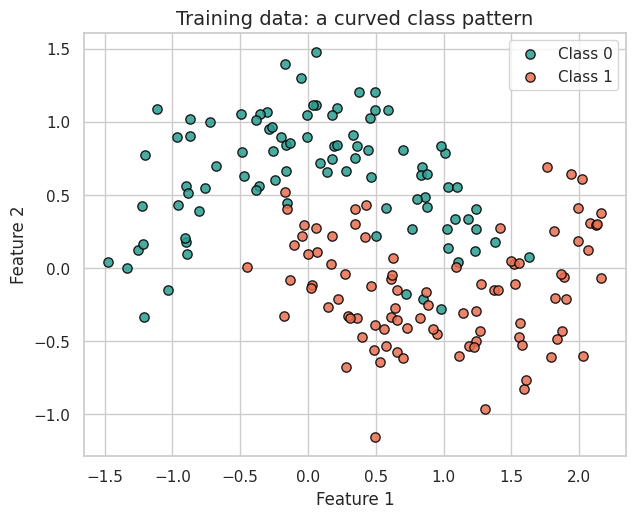

In [53]:
X, y = make_moons(n_samples=260, noise=0.25, random_state=12)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

feature_names = ["Feature 1", "Feature 2"]

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Training class counts:", dict(zip(*np.unique(y_train, return_counts=True))))

fig, ax = plt.subplots(figsize=(7, 5.5))
for label, name in [(0, "Class 0"), (1, "Class 1")]:
    mask = y_train == label
    ax.scatter(X_train[mask, 0], X_train[mask, 1], s=45,
               color=CLASS_COLORS[label], edgecolor="black", alpha=0.85, label=name)

ax.set(xlabel=feature_names[0], ylabel=feature_names[1],
       title="Training data: a curved class pattern")
ax.legend()
plt.show()


In [59]:
sklearn_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    min_samples_leaf=3,
    random_state=42,
)

sklearn_tree.fit(X_train, y_train)
sklearn_predictions = sklearn_tree.predict(X_test)
sklearn_predictions_train = sklearn_tree.predict(X_train)
print(accuracy_score(y_test, sklearn_predictions))
print(accuracy_score(y_train, sklearn_predictions_train))

0.9230769230769231
0.9065934065934066


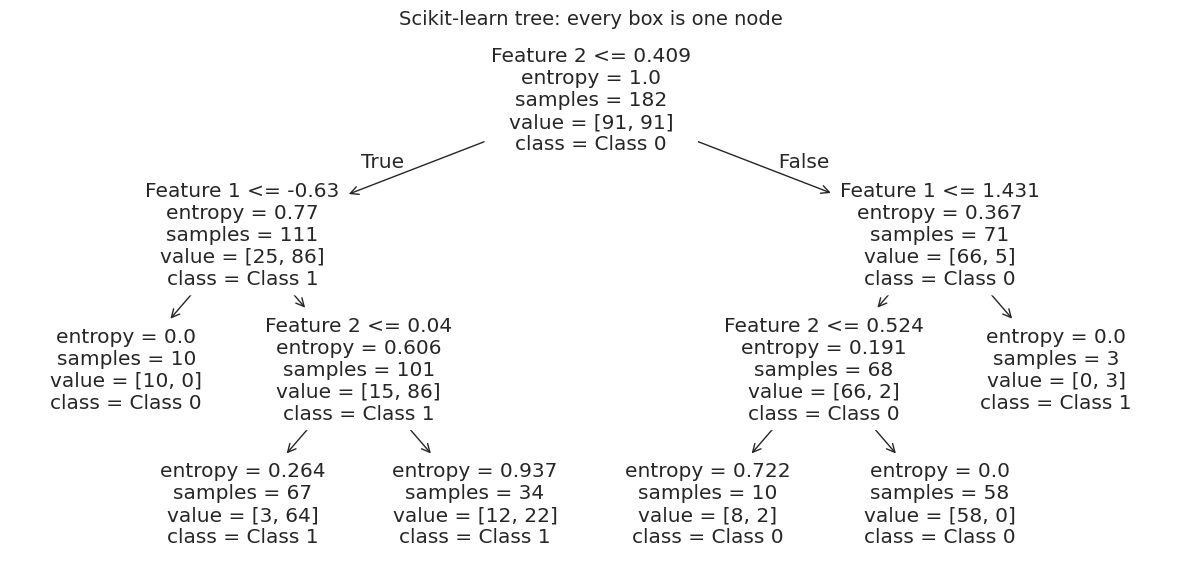

In [60]:
fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(
    sklearn_tree,
    feature_names=feature_names,
    class_names=["Class 0", "Class 1"],
    filled=False,
    rounded=True,
    impurity=True,
    proportion=False,
    ax=ax,
)
ax.set_title("Scikit-learn tree: every box is one node")
plt.show()
